In [7]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

In [10]:
# number from yeast_string_genes.txt
yeast_coexpression_matrix = np.zeros((6400, 6400))

with open('../../data/networks/yeast/yeast_string_coexpression_adjacency.txt', 'r') as f :
    for line in f:
        a, b, weight = line.strip().split('\t')
        a = int(a)
        b = int(b)
        weight = float(weight)

        yeast_coexpression_matrix[a][b] = weight
        yeast_coexpression_matrix[b][a] = weight

(array([123370., 203462.,  81108.,  47768.,  31428.,  21954.,  21226.,
         21530.,  20932.,  55248.]),
 array([0.064 , 0.1575, 0.251 , 0.3445, 0.438 , 0.5315, 0.625 , 0.7185,
        0.812 , 0.9055, 0.999 ]),
 <BarContainer object of 10 artists>)

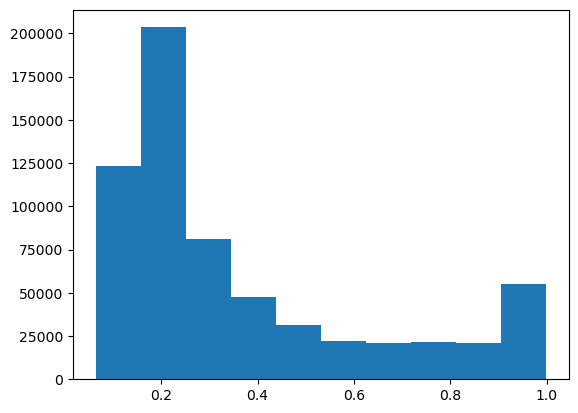

In [12]:
yeast_flat = yeast_coexpression_matrix.ravel()
yeast_nonzero = []
for i in yeast_flat :
    if i != 0 :
        yeast_nonzero.append(i)
plt.hist(yeast_nonzero)
# plt.yscale('log')

In [13]:
G = nx.from_numpy_array(yeast_coexpression_matrix)
avg_clustering = nx.average_clustering(G)
print("Average clustering coefficient:", avg_clustering)


Average clustering coefficient: 0.38414003201564895


In [16]:
print("Density:", nx.density(G))
bet_cent = nx.betweenness_centrality(G, k=200)
print("Sample betweeness centrality:", bet_cent)

Density: 0.015335062119081106
Sample betweeness centrality: {0: 0.0, 1: 0.0, 2: 0.0, 3: 0.0, 4: 2.945670070087278e-06, 5: 0.0, 6: 0.0, 7: 2.6375206558224837e-07, 8: 1.679299456711946e-06, 9: 1.679299456711946e-06, 10: 0.0, 11: 0.0, 12: 1.2854120861959788e-05, 13: 0.0, 14: 4.408824007295885e-08, 15: 3.078403056552072e-07, 16: 4.408824007295885e-08, 17: 4.408824007295885e-08, 18: 4.202853943744266e-05, 19: 0.0, 20: 0.0, 21: 0.0, 22: 0.0, 23: 9.842138200816661e-05, 24: 0.0, 25: 5.927816379406574e-06, 26: 0.0, 27: 0.0, 28: 0.0, 29: 0.0, 30: 0.0, 31: 0.0, 32: 0.00018482141624351654, 33: 0.0005938924003102579, 34: 6.562561132536945e-06, 35: 0.0007021996994767225, 36: 0.00014059205735879877, 37: 0.0002412061308065003, 38: 1.836813323528155e-06, 39: 0.0, 40: 3.705676803343768e-08, 41: 0.00039636542303261087, 42: 5.235933811840087e-05, 43: 1.302514300761139e-05, 44: 3.4661137906661675e-05, 45: 5.414393770755063e-05, 46: 0.00042554032953231845, 47: 0.0005585223073986197, 48: 0.000835712377836836

(array([2.648e+03, 8.390e+02, 5.200e+02, 3.170e+02, 2.140e+02, 1.540e+02,
        1.560e+02, 1.330e+02, 1.170e+02, 9.500e+01, 7.300e+01, 6.600e+01,
        6.700e+01, 6.100e+01, 4.800e+01, 4.500e+01, 4.600e+01, 5.400e+01,
        4.300e+01, 3.800e+01, 5.400e+01, 4.200e+01, 3.800e+01, 4.500e+01,
        4.400e+01, 4.700e+01, 3.700e+01, 3.800e+01, 3.500e+01, 3.500e+01,
        3.400e+01, 3.700e+01, 2.500e+01, 2.500e+01, 2.100e+01, 2.500e+01,
        1.100e+01, 1.400e+01, 8.000e+00, 1.000e+01, 8.000e+00, 6.000e+00,
        7.000e+00, 6.000e+00, 2.000e+00, 4.000e+00, 3.000e+00, 2.000e+00,
        2.000e+00, 1.000e+00]),
 array([  0.,  17.,  34.,  51.,  68.,  85., 102., 119., 136., 153., 170.,
        187., 204., 221., 238., 255., 272., 289., 306., 323., 340., 357.,
        374., 391., 408., 425., 442., 459., 476., 493., 510., 527., 544.,
        561., 578., 595., 612., 629., 646., 663., 680., 697., 714., 731.,
        748., 765., 782., 799., 816., 833., 850.]),
 <BarContainer object of 50 

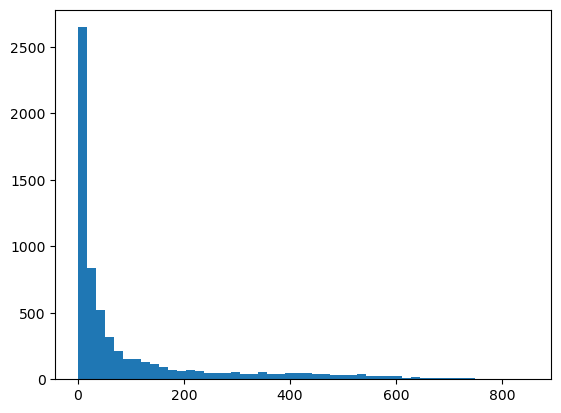

In [17]:
degrees = list(dict(G.degree()).values())
plt.hist(degrees, bins=50)
